adj_close shape: (3806, 9)
volume shape   : (3806, 9)
daily_ret shape: (3806, 9)
n_rebalance_dates: 790
first rebalance date: 2011-01-07 00:00:00
last rebalance date : 2026-02-20 00:00:00
EQW   : 2011-01-03 00:00:00 -> 2026-02-20 00:00:00
MOM_W : 2011-01-03 00:00:00 -> 2026-02-20 00:00:00
MOM_L : 2011-01-03 00:00:00 -> 2026-02-20 00:00:00

Signal history sample:


,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
2012-01-06,-0.106893,0.027939,-0.185218,-0.021935,0.003822,0.151871,0.187309,0.103991,0.051790
2012-01-13,-0.084742,0.012282,-0.185263,-0.015737,0.007893,0.128510,0.149804,0.114173,0.073289
2012-01-20,-0.016264,0.005741,-0.146454,0.010155,0.029871,0.121689,0.138006,0.123339,0.084995
2012-01-27,-0.011885,0.019155,-0.115404,0.031235,0.053796,0.150662,0.139574,0.157511,0.127417
2012-02-03,-0.040589,-0.020995,-0.135188,0.012933,0.023646,0.131773,0.138132,0.130785,0.102378



Weights sample:


,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
2011-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Target weights sample:


,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY
2011-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011-01-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Returns sample:


,EQW_net,DualMoM_W_net,DualMoM_L_net
2011-01-03,0.0000,0.0,0.0
2011-01-04,0.0000,0.0,0.0
2011-01-05,0.0000,0.0,0.0
2011-01-06,0.0000,0.0,0.0
2011-01-07,-0.0005,0.0,0.0



Metrics:


,n_days,CAGR,Vol,Sharpe,MaxDD,HitRate
series,,,,,,
DualMoM_L_net,3806,0.109681,0.184247,0.657459,-0.468357,0.502890
DualMoM_W_net,3806,0.128167,0.161296,0.828628,-0.302967,0.503941
EQW_net,3806,0.127155,0.164791,0.809226,-0.369803,0.550184


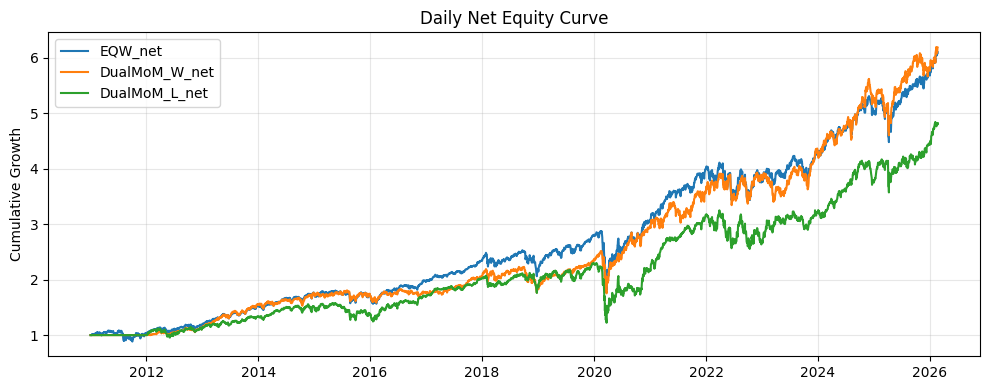

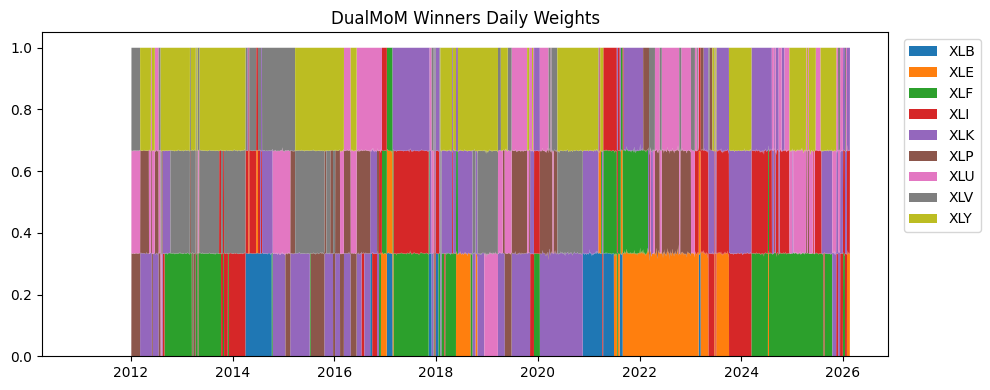

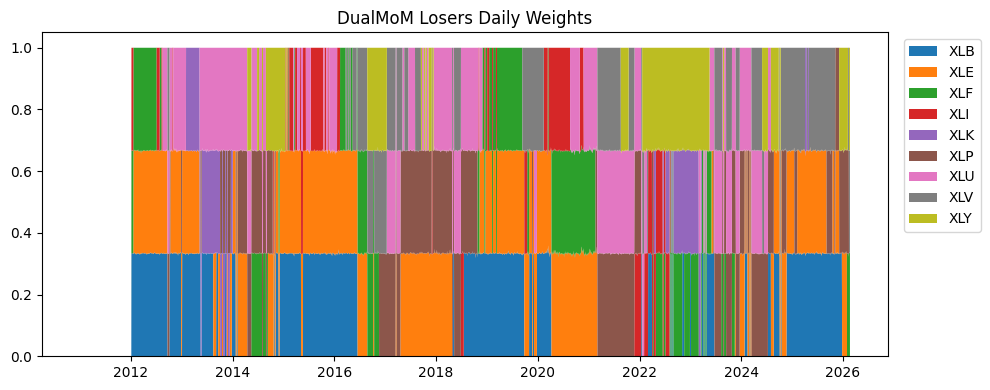

In [2]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# 0. Data load
# =========================
df = pd.read_csv("data/us_sector_etf_9_ohlc.csv", header=[0, 1], index_col=0)
df.index = pd.to_datetime(df.index)

START_DATE = df.index[0]
COST_BPS = 10
TOP_K = 3

# モメンタム計算用
# 過去 LOOKBACK_WEEKS 週のうち、直近 SKIP_WEEKS 週を除外
LOOKBACK_WEEKS = 52
SKIP_WEEKS = 1

adj_close = df["Adj Close"].copy()
volume = df["Volume"].copy()

adj_close = adj_close.loc[adj_close.index >= START_DATE].astype(float).ffill()
volume = volume.loc[volume.index >= START_DATE].astype(float)

daily_ret = adj_close.pct_change()

print("adj_close shape:", adj_close.shape)
print("volume shape   :", volume.shape)
print("daily_ret shape:", daily_ret.shape)


# =========================
# 1. Utilities
# =========================
def make_weekly_rebalance_calendar(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """
    各週の最終営業日をリバランス日とする。
    """
    week_key = index.to_period("W-FRI")
    rebalance_dates = pd.Series(index, index=index).groupby(week_key).max()
    return pd.DatetimeIndex(rebalance_dates.values).sort_values().unique()


def compute_signal_from_weekly_return_history(
    weekly_return_history: list[pd.Series],
    lookback_weeks: int,
    skip_weeks: int,
    asset_names: list[str],
    current_date: pd.Timestamp,
) -> pd.Series | None:
    """
    確定済みの週次リターン履歴から、その時点の最新モメンタムシグナルを計算する。

    モメンタム定義:
        mom_t = product(1 + r_w) - 1
    ただし、直近 skip_weeks 週は除外し、
    その前の lookback_weeks - skip_weeks 週を使う。

    weekly_return_history:
        各要素は「その週の週次リターン」の pd.Series
    """
    if len(weekly_return_history) < lookback_weeks:
        return None

    weekly_ret = pd.DataFrame(weekly_return_history)
    weekly_ret.index = [x.name for x in weekly_return_history]
    weekly_ret = weekly_ret.reindex(columns=asset_names).sort_index()

    # 最新週を末尾としたとき、
    # [-(lookback_weeks) : -(skip_weeks)] を使うイメージ
    # 例: lookback=52, skip=1 なら直近1週を除いた過去51週
    start_idx = len(weekly_ret) - lookback_weeks
    end_idx = len(weekly_ret) - skip_weeks

    if start_idx < 0 or end_idx <= start_idx:
        return None

    window = weekly_ret.iloc[start_idx:end_idx].copy()
    if len(window) == 0:
        return None

    # リターン系列から累積モメンタムを計算
    signal = (1.0 + window).prod(axis=0, min_count=1) - 1.0
    signal = signal.reindex(asset_names)
    signal.name = current_date

    if signal.notna().sum() == 0:
        return None

    return signal


def select_target_weights_eqw(
    tradable_row: pd.Series,
    all_assets: list[str],
) -> pd.Series | None:
    valid_assets = tradable_row[tradable_row.notna()].index.tolist()
    if len(valid_assets) == 0:
        return None

    w = pd.Series(0.0, index=all_assets, dtype=float)
    w.loc[valid_assets] = 1.0 / len(valid_assets)
    return w


def select_target_weights_mom(
    signal_row: pd.Series,
    tradable_row: pd.Series,
    all_assets: list[str],
    momentum_high: bool = True,
    top_k: int = 3,
) -> pd.Series | None:
    valid = signal_row.notna() & tradable_row.notna()
    if valid.sum() < max(top_k, 1):
        return None

    score = signal_row[valid].copy()
    score = score.replace([np.inf, -np.inf], np.nan).dropna()

    if score.empty:
        return None

    if momentum_high:
        selected = score.sort_values(ascending=False).head(top_k).index
    else:
        selected = score.sort_values(ascending=False).tail(top_k).index

    if len(selected) == 0:
        return None

    w = pd.Series(0.0, index=all_assets, dtype=float)
    w.loc[selected] = 1.0 / len(selected)
    return w


def annualized_metrics(ret: pd.Series, periods_per_year: int = 252) -> dict:
    ret = ret.dropna()
    if len(ret) == 0:
        return {
            "n_days": 0,
            "CAGR": np.nan,
            "Vol": np.nan,
            "Sharpe": np.nan,
            "MaxDD": np.nan,
            "HitRate": np.nan,
        }

    equity = (1.0 + ret).cumprod()
    years = len(ret) / periods_per_year
    cagr = equity.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan
    vol = ret.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = (ret.mean() * periods_per_year) / vol if vol and vol > 0 else np.nan
    dd = equity / equity.cummax() - 1.0
    maxdd = dd.min()
    hitrate = (ret > 0).mean()

    return {
        "n_days": int(len(ret)),
        "CAGR": float(cagr),
        "Vol": float(vol),
        "Sharpe": float(sharpe),
        "MaxDD": float(maxdd),
        "HitRate": float(hitrate),
    }


def plot_equity_curve(ret_df: pd.DataFrame, title: str):
    ret_df = ret_df.dropna(how="all")
    eq = (1.0 + ret_df.fillna(0.0)).cumprod()

    fig, ax = plt.subplots(figsize=(10, 4))
    for col in eq.columns:
        ax.plot(eq.index, eq[col], label=col)
    ax.set_title(title)
    ax.set_ylabel("Cumulative Growth")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()


def plot_weights(weights: pd.DataFrame, title: str):
    weights = weights.fillna(0.0)

    fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)
    ax.set_title(title)
    ax.stackplot(weights.index, weights.T, labels=weights.columns)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.show()


# =========================
# 2. Result container
# =========================
@dataclass
class StrategyResult:
    name: str
    ret_gross: pd.Series
    turnover: pd.Series
    ret_net: pd.Series
    weights: pd.DataFrame
    target_weights: pd.DataFrame
    signal_history: pd.DataFrame


# =========================
# 3. Main backtest
# =========================
def run_daily_walkforward_strategy_fast(
    adj_close_daily: pd.DataFrame,
    rebalance_dates: pd.DatetimeIndex,
    strategy_name: str,
    mode: str,
    top_k: int = 3,
    lookback_weeks: int = 52,
    skip_weeks: int = 1,
    cost_bps: float = 10.0,
) -> StrategyResult:
    """
    日次ループ内で週次リターン履歴を逐次構築し、
    その週次リターン系列からモメンタムシグナルを作る高速版。

    mode:
      - 'eqw'
      - 'winners'
      - 'losers'

    タイミング:
      1. 前日引け後ウェイトで当日損益を受ける
      2. 当日リターンでウェイトをドリフト更新
      3. 当日が週次リバランス日なら、その日までの週次リターン履歴だけでシグナルを構築
      4. 当日引けで目標ウェイトへ付け替え
      5. 取引コストを当日控除
      6. 翌日へ引け後ウェイトを持ち越す
    """
    adj_close_daily = adj_close_daily.astype(float).sort_index().ffill()
    daily_ret = adj_close_daily.pct_change()
    assets = list(adj_close_daily.columns)
    dates = daily_ret.index

    rebalance_dates = pd.DatetimeIndex(rebalance_dates).intersection(dates)
    rebalance_set = set(rebalance_dates)

    current_w = pd.Series(0.0, index=assets, dtype=float)
    current_target = pd.Series(0.0, index=assets, dtype=float)

    gross_records = []
    turnover_records = []
    net_records = []
    weights_records = []
    target_records = []
    signal_records = []

    # 週次終値と週次リターンを逐次更新
    weekly_close_history = []
    weekly_return_history = []

    prev_week = None
    current_week_last_price = None
    current_week_last_date = None

    for dt in dates:
        r_t = daily_ret.loc[dt].fillna(0.0)
        tradable_today = adj_close_daily.loc[dt]
        week_t = dt.to_period("W-FRI")

        # -------------------------
        # 週次終値履歴の逐次更新
        # -------------------------
        if prev_week is None:
            prev_week = week_t
            current_week_last_price = tradable_today.copy()
            current_week_last_date = dt
        elif week_t == prev_week:
            current_week_last_price = tradable_today.copy()
            current_week_last_date = dt
        else:
            # 前週終値を確定
            finalized_close = current_week_last_price.rename(current_week_last_date)
            weekly_close_history.append(finalized_close)

            # 前週の週次リターンを確定
            if len(weekly_close_history) >= 2:
                prev_close = weekly_close_history[-2]
                curr_close = weekly_close_history[-1]
                weekly_ret = (curr_close / prev_close) - 1.0
                weekly_ret.name = curr_close.name
                weekly_return_history.append(weekly_ret)

            prev_week = week_t
            current_week_last_price = tradable_today.copy()
            current_week_last_date = dt

        # 当日がリバランス日なら、その日価格を用いた最新週の週次リターンを一時的に追加
        temp_weekly_return_history = weekly_return_history.copy()
        if dt in rebalance_set:
            temp_current_close = tradable_today.rename(dt)

            temp_weekly_close_history = weekly_close_history.copy()
            temp_weekly_close_history.append(temp_current_close)

            if len(temp_weekly_close_history) >= 2:
                prev_close = temp_weekly_close_history[-2]
                curr_close = temp_weekly_close_history[-1]
                temp_weekly_ret = (curr_close / prev_close) - 1.0
                temp_weekly_ret.name = curr_close.name
                temp_weekly_return_history.append(temp_weekly_ret)

        # -------------------------
        # 1. 前日引け後ウェイトで当日損益
        # -------------------------
        gross_ret_t = float((current_w * r_t).sum())

        # -------------------------
        # 2. ドリフト後ウェイト
        # -------------------------
        if current_w.abs().sum() == 0:
            drifted_w = current_w.copy()
        elif (1.0 + gross_ret_t) <= 0:
            drifted_w = pd.Series(0.0, index=assets, dtype=float)
        else:
            drifted_w = current_w * (1.0 + r_t)
            drifted_w = drifted_w / (1.0 + gross_ret_t)
            drifted_w = drifted_w.fillna(0.0)

        turnover_t = 0.0
        post_trade_w = drifted_w.copy()

        signal_row_to_store = pd.Series(np.nan, index=assets, dtype=float, name=dt)

        # -------------------------
        # 3. リバランス日ならシグナル構築・売買
        # -------------------------
        if dt in rebalance_set:
            if mode == "eqw":
                new_target = select_target_weights_eqw(
                    tradable_row=tradable_today,
                    all_assets=assets,
                )
            else:
                signal_row = compute_signal_from_weekly_return_history(
                    weekly_return_history=temp_weekly_return_history,
                    lookback_weeks=lookback_weeks,
                    skip_weeks=skip_weeks,
                    asset_names=assets,
                    current_date=dt,
                )

                if signal_row is not None:
                    signal_row_to_store = signal_row.copy()

                    new_target = select_target_weights_mom(
                        signal_row=signal_row,
                        tradable_row=tradable_today,
                        all_assets=assets,
                        momentum_high=(mode == "winners"),
                        top_k=top_k,
                    )
                else:
                    new_target = None

            if new_target is not None:
                turnover_t = float(0.5 * (new_target - drifted_w).abs().sum())
                post_trade_w = new_target.copy()
                current_target = new_target.copy()

        # -------------------------
        # 4. コスト控除
        # -------------------------
        net_ret_t = gross_ret_t - turnover_t * (cost_bps / 10000.0)

        gross_records.append((dt, gross_ret_t))
        turnover_records.append((dt, turnover_t))
        net_records.append((dt, net_ret_t))
        weights_records.append(post_trade_w.rename(dt))
        target_records.append(current_target.rename(dt))
        signal_records.append(signal_row_to_store)

        current_w = post_trade_w.copy()

    ret_gross = pd.Series(dict(gross_records), name=f"{strategy_name}_gross").sort_index()
    turnover = pd.Series(dict(turnover_records), name=f"{strategy_name}_turnover").sort_index()
    ret_net = pd.Series(dict(net_records), name=f"{strategy_name}_net").sort_index()
    weights = pd.DataFrame(weights_records).sort_index()
    target_weights = pd.DataFrame(target_records).sort_index()
    signal_history = pd.DataFrame(signal_records).sort_index()

    diff = (ret_gross - ret_net - turnover * (cost_bps / 10000.0)).abs().max()
    assert diff < 1e-12, f"cost consistency failed for {strategy_name}: {diff}"

    return StrategyResult(
        name=strategy_name,
        ret_gross=ret_gross,
        turnover=turnover,
        ret_net=ret_net,
        weights=weights,
        target_weights=target_weights,
        signal_history=signal_history,
    )


# =========================
# 4. Run
# =========================
rebalance_dates = make_weekly_rebalance_calendar(adj_close.index)

print("n_rebalance_dates:", len(rebalance_dates))
print("first rebalance date:", rebalance_dates[0])
print("last rebalance date :", rebalance_dates[-1])

eqw = run_daily_walkforward_strategy_fast(
    adj_close_daily=adj_close,
    rebalance_dates=rebalance_dates,
    strategy_name="EQW",
    mode="eqw",
    top_k=TOP_K,
    lookback_weeks=LOOKBACK_WEEKS,
    skip_weeks=SKIP_WEEKS,
    cost_bps=COST_BPS,
)

mom_w = run_daily_walkforward_strategy_fast(
    adj_close_daily=adj_close,
    rebalance_dates=rebalance_dates,
    strategy_name="DualMoM_W",
    mode="winners",
    top_k=TOP_K,
    lookback_weeks=LOOKBACK_WEEKS,
    skip_weeks=SKIP_WEEKS,
    cost_bps=COST_BPS,
)

mom_l = run_daily_walkforward_strategy_fast(
    adj_close_daily=adj_close,
    rebalance_dates=rebalance_dates,
    strategy_name="DualMoM_L",
    mode="losers",
    top_k=TOP_K,
    lookback_weeks=LOOKBACK_WEEKS,
    skip_weeks=SKIP_WEEKS,
    cost_bps=COST_BPS,
)

print("EQW   :", eqw.ret_net.dropna().index.min(), "->", eqw.ret_net.dropna().index.max())
print("MOM_W :", mom_w.ret_net.dropna().index.min(), "->", mom_w.ret_net.dropna().index.max())
print("MOM_L :", mom_l.ret_net.dropna().index.min(), "->", mom_l.ret_net.dropna().index.max())


# =========================
# 5. Outputs
# =========================
strategy_returns = pd.concat(
    [
        eqw.ret_net,
        mom_w.ret_net,
        mom_l.ret_net,
    ],
    axis=1,
).sort_index()

metrics_rows = []
for c in strategy_returns.columns:
    m = annualized_metrics(strategy_returns[c], periods_per_year=252)
    m["series"] = c
    metrics_rows.append(m)

metrics_summary = pd.DataFrame(metrics_rows).set_index("series").sort_index()

print("\nSignal history sample:")
display(mom_w.signal_history.dropna(how="all").head())

print("\nWeights sample:")
display(mom_w.weights.head())

print("\nTarget weights sample:")
display(mom_w.target_weights.head())

print("\nReturns sample:")
display(strategy_returns.head())

print("\nMetrics:")
display(metrics_summary)


# =========================
# 6. Plots
# =========================
plot_equity_curve(strategy_returns, "Daily Net Equity Curve")
plot_weights(mom_w.weights, "DualMoM Winners Daily Weights")
plot_weights(mom_l.weights, "DualMoM Losers Daily Weights")

In [54]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
df = pd.read_csv("data/us_sector_etf_9_ohlc.csv", header=[0, 1], index_col=0)
df.index = pd.to_datetime(df.index)

START_DATE = df.index[0]
COST_BPS = 10
TOP_K = 3

adj_close = df['Adj Close'].copy()
volume = df['Volume'].copy()
adj_close = adj_close.loc[adj_close.index >= START_DATE]
volume = volume.loc[volume.index >= START_DATE]
adj_close = adj_close.astype(float).ffill()
volume = volume.astype(float)

In [56]:
def monthly_from_daily(adj_close_daily: pd.DataFrame, volume_daily: pd.DataFrame):
    monthly_price = adj_close_daily.resample('ME').last()
    monthly_ret = monthly_price.pct_change()
    monthly_vol_sum = volume_daily.resample('ME').sum(min_count=1)
    monthly_mom = monthly_price.shift(2) / monthly_price.shift(12) - 1
    return monthly_price, monthly_ret, monthly_vol_sum, monthly_mom

def monthly_excluding_last_3_days(adj_close_daily: pd.DataFrame, volume_daily: pd.DataFrame):
    idx = adj_close_daily.index
    month_key = idx.to_period('M')
    rank_from_end = idx.to_series(index=idx).groupby(month_key).cumcount(ascending=False) + 1
    keep_mask = rank_from_end > 3
    # Keep only rows excluding each month's last 3 trading days.
    adj_keep = adj_close_daily.loc[keep_mask.values].copy()
    vol_keep = volume_daily.loc[keep_mask.values].copy()
    month_key_keep = adj_keep.index.to_period('M')
    price_eom = adj_keep.groupby(month_key_keep).last()
    vol_eom = vol_keep.groupby(month_key_keep).sum(min_count=1)
    price_eom.index = price_eom.index.to_timestamp(how='end').normalize()
    vol_eom.index = vol_eom.index.to_timestamp(how='end').normalize()
    ret_eom = price_eom.pct_change()
    mom_eom = price_eom.shift(2) / price_eom.shift(12) - 1
    return price_eom, ret_eom, vol_eom, mom_eom

In [57]:
monthly_price, monthly_ret, monthly_vol, momentum_proxy = monthly_from_daily(adj_close, volume)
monthly_price_eom, monthly_ret_eom, monthly_vol_eom, momentum_proxy_eom = monthly_excluding_last_3_days(adj_close, volume)
print('monthly rows:', len(monthly_ret))
print('monthly rows (EOM excl.):', len(monthly_ret_eom))

monthly rows: 182
monthly rows (EOM excl.): 182


In [58]:
@dataclass
class StrategyResult:
    name: str
    ret_gross: pd.Series
    turnover: pd.Series
    ret_net: pd.Series
    weights: pd.DataFrame

In [59]:
def build_eqw_strategy(
    monthly_ret: pd.DataFrame,
    strategy_name: str,
    cost_bps: float = 10.0,
) -> StrategyResult:
    months = monthly_ret.index
    assets = list(monthly_ret.columns)

    w_list = []
    gross = []
    one_way_turn = []
    prev_w = pd.Series(0.0, index=assets)

    for i in range(len(months) - 1):
        m = months[i]
        h = months[i + 1]

        r_form = monthly_ret.loc[m]
        r_hold = monthly_ret.loc[h]

        valid = r_hold.notna()
        if valid.sum() < 4:
            continue

        rv = r_form[valid]
        w_assets = rv.index

        if len(w_assets) == 0:
            continue

        w = pd.Series(0.0, index=assets)
        w.loc[w_assets] = 1.0 / len(w_assets)

        assert h > m, f'holding month must be after formation month: {m} -> {h}'

        g = float((w * r_hold).sum())
        t = float(0.5 * (w - prev_w).abs().sum())
        n = g - t * (cost_bps / 10000.0)

        w_list.append(w.rename(h))
        gross.append((h, g))
        one_way_turn.append((h, t))
        prev_w = w
    
    if not w_list:
        raise ValueError(f'No valid monthly portfolios for {strategy_name}')

    W = pd.DataFrame(w_list)
    ret_gross = pd.Series(dict(gross), name=f'{strategy_name}_gross').sort_index()
    turn = pd.Series(dict(one_way_turn), name=f'{strategy_name}_turnover').sort_index()
    ret_net = (ret_gross - turn * (cost_bps / 10000.0)).rename(f'{strategy_name}_net')

    diff = (ret_gross - ret_net - turn * (cost_bps / 10000.0)).abs().max()
    assert diff < 1e-12, f'cost consistency failed for {strategy_name}: {diff}'

    return StrategyResult(strategy_name, ret_gross, turn, ret_net, W.sort_index())

def build_mom_strategy(
    monthly_ret: pd.DataFrame,
    momentum_signal: pd.DataFrame,
    strategy_name: str,
    momentum_high: bool = True,
    top_k: int = 3,
    cost_bps: float = 10.0,
) -> StrategyResult:
    months = monthly_ret.index
    assets = list(monthly_ret.columns)

    w_list = []
    gross = []
    one_way_turn = []
    prev_w = pd.Series(0.0, index=assets)

    for i in range(len(months) - 1):
        m = months[i]
        h = months[i + 1]

        r_form = monthly_ret.loc[m]
        m_form = momentum_signal.loc[m]
        r_hold = monthly_ret.loc[h]

        valid = r_form.notna() & m_form.notna() & r_hold.notna()
        if valid.sum() < 4:
            continue
        
        score = m_form[valid].copy()
        abs_score = m_form[valid].copy()
        score = score.where(abs_score > 0)
        
        w_assets = score.sort_values(ascending=False).dropna().head(top_k).index
        l_assets = score.sort_values(ascending=False).dropna().tail(top_k).index

        if len(w_assets) == 0 or len(l_assets) == 0:
            continue

        w = pd.Series(0.0, index=assets)
        if momentum_high:
            w.loc[w_assets] = 1.0 / len(w_assets)
        else:
            w.loc[l_assets] = 1.0 / len(l_assets)

        assert h > m, f'holding month must be after formation month: {m} -> {h}'

        g = float((w * r_hold).sum())
        t = float(0.5 * (w - prev_w).abs().sum())
        n = g - t * (cost_bps / 10000.0)

        w_list.append(w.rename(h))
        gross.append((h, g))
        one_way_turn.append((h, t))
        prev_w = w

    if not w_list:
        raise ValueError(f'No valid monthly portfolios for {strategy_name}')

    W = pd.DataFrame(w_list)
    ret_gross = pd.Series(dict(gross), name=f'{strategy_name}_gross').sort_index()
    turn = pd.Series(dict(one_way_turn), name=f'{strategy_name}_turnover').sort_index()
    ret_net = (ret_gross - turn * (cost_bps / 10000.0)).rename(f'{strategy_name}_net')

    diff = (ret_gross - ret_net - turn * (cost_bps / 10000.0)).abs().max()
    assert diff < 1e-12, f'cost consistency failed for {strategy_name}: {diff}'

    return StrategyResult(strategy_name, ret_gross, turn, ret_net, W.sort_index())

eqw = build_eqw_strategy(
    monthly_ret = monthly_ret,
    strategy_name = 'EQW',
    cost_bps = COST_BPS,
)

mom_w = build_mom_strategy(
    monthly_ret = monthly_ret,
    momentum_signal = momentum_proxy,
    strategy_name = 'DualMoM_W',
    momentum_high = True,
    top_k = TOP_K,
    cost_bps=COST_BPS,
)

mom_l = build_mom_strategy(
    monthly_ret = monthly_ret,
    momentum_signal = momentum_proxy,
    strategy_name = 'DualMoM_L',
    momentum_high = False,
    top_k = TOP_K,
    cost_bps=COST_BPS,
)

In [60]:
def annualized_metrics(ret: pd.Series, periods_per_year: int = 12) -> dict:
    ret = ret.dropna()
    if len(ret) == 0:
        return {'n_months': 0, 'CAGR': np.nan, 'Vol': np.nan, 'Sharpe': np.nan, 'MaxDD': np.nan, 'HitRate': np.nan}

    equity = (1 + ret).cumprod()
    years = len(ret) / periods_per_year
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = ret.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = (ret.mean() * periods_per_year) / vol if vol and vol > 0 else np.nan
    dd = equity / equity.cummax() - 1
    maxdd = dd.min()
    hit = (ret > 0).mean()

    return {
        'n_months': int(len(ret)),
        'CAGR': float(cagr),
        'Vol': float(vol),
        'Sharpe': float(sharpe),
        'MaxDD': float(maxdd),
        'HitRate': float(hit),
    }

strategy_returns = pd.concat([
    eqw.ret_net,
    mom_w.ret_net,
    mom_l.ret_net,
], axis=1).sort_index()

metrics_rows = []
for c in strategy_returns.columns:
    if c.endswith('_gross') or c.endswith('_net'):
        m = annualized_metrics(strategy_returns[c])
        m['series'] = c
        metrics_rows.append(m)

metrics_summary = pd.DataFrame(metrics_rows).set_index('series').sort_index()
metrics_summary

,n_months,CAGR,Vol,Sharpe,MaxDD,HitRate
series,,,,,,
DualMoM_L_net,169,0.122990,0.142042,0.891673,-0.254958,0.656805
DualMoM_W_net,169,0.131209,0.139313,0.959174,-0.196503,0.656805
EQW_net,181,0.126457,0.137374,0.939558,-0.235995,0.690608


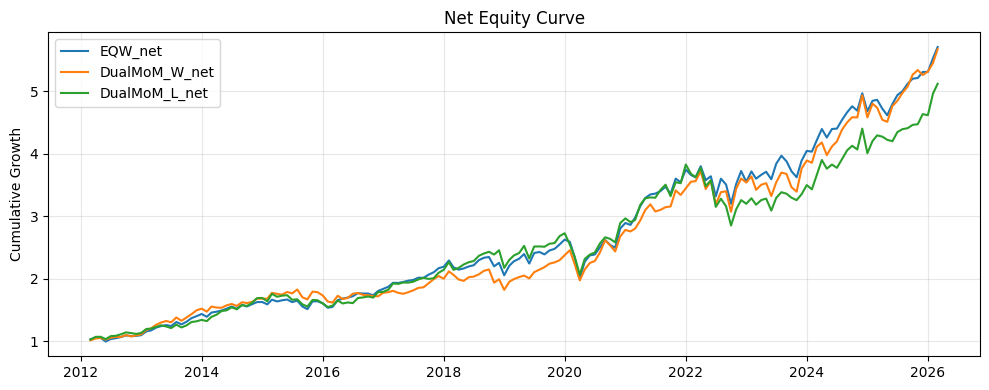

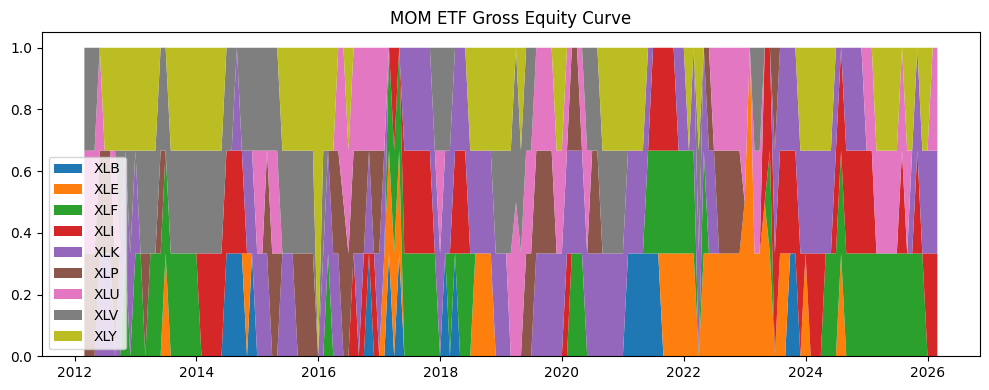

In [61]:
def plot_equity_curve(ret_series: pd.Series, title: str):
    ret_series = ret_series.dropna()
    eq = (1 + ret_series.dropna()).cumprod()
    fig, ax = plt.subplots(figsize=(10, 4))
    for item in eq.columns:
        ax.plot(eq[item], label=item)
    ax.set_title(title)
    ax.set_ylabel('Cumulative Growth')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

def plot_weights(weights, title):
    fig, ax = plt.subplots(figsize=(10, 4), tight_layout=True)
    ax.set_title(title)
    ax.stackplot(weights.index, weights.T, labels=weights.columns)
    ax.legend()
    plt.show()

plot_equity_curve(strategy_returns, 'Net Equity Curve')
plot_weights(mom_w.weights, 'MOM ETF Gross Equity Curve')